#Questions to Answer:

1) Given one randomly placed large food source, how long does it take the colony to converge on said solution? (How many trials of this are you going to run?) **Here, we will define convergence as the time 90% of the food has been returned.**

&emsp;&emsp;&emsp; a) Optimized for varying Evaporation Rates? Pheromone Diffusion Rates?

&emsp;&emsp;&emsp; b) What kind of behaviors do the ants exhibit under the extremes for evaporation rate and pheromone diffusion rate?

&emsp;&emsp;&emsp; c) How does the efficiency of these solutions scale with the number of ants?

&emsp;&emsp;&emsp; d) What is the maximum efficiency achieved? Minimum? In general, how efficient is this algorithm? **Here, we will define two types of efficiencies: time efficiency and distance efficiency (we are more interested in this). **

2) Extend these questions for multiple food sources. Begin with multiple food sources of the same size. Next, vary the sizes of the food sources. (Run at least one trial with one food source significantly weighted more than the other food sources. Use a minimum of 3 food sources for all trials.) Test both manual placement of these food sources and random placement.

3) Extend questions 1 and 2 for a stagnant food source but moving colony. (Research: Under what conditions does the colony move? Which of these conditions is more valuable to test under?)

4) What real-life ant behaviors does this model fail to account for? Identify other weaknesses in this model.

5) In what spaces could this model potentially be applied? In what ways is this model useful? Are there isolated portions of the model that are more useful than others?


#Key Assumptions and Answers to Questions Raised under Primary Interests:

1) The Ants:

The ants travel along the points of the grid. Each ant exists at an integer coordinate contained at (row, column). They are already moving along discrete lattice locations but each point is visualized as a square with each ant at center. Each location is treated like a cell.

The ants are filtered into the following states: inside the colony, searching and returning

* Define an experimental parameter (search_fraction) to be a fraction of the total colony of ants out searching for food -> can be experimentally varied
* Can introduce another parameter (colony rest period) that establishes a wait time between resting ants and searching ants -> will set this to a number of simulation steps before becoming searching ants again
* The experimental arena is physically bounded
* Before food has been found, the ants at random pick one of the 4 surrounding points. The baseline here is an unbiased random walk. Every random walk is seeded differently.




**Exploration Grounds:**

*   10 x 16 box grid

**Controls:**

*  Evaporation Rate
*  Pheromone Diffusion Rate

**Potential Ant States:**
Each ant is an individual object with a position and behavioral state.

* Searching
* Returning

 The **Pheromone Field**, P, is governed by the equation:

&emsp; $\frac{∂P}{∂t} = D∇^2P - \lambda P + S$

where:


*   D is the pheromone diffusion rate
*   $\lambda$ is the evaporation rate
*   the $\nabla^2 P$ term spreads the pheromones into adjacent cells
*   S is the pheromone deposited by the ants

The pheromone concentration is stored as a 10 x 16 numerical array and updated using the diffusion equation.

#Build Model:

In [ ]:
from __future__ import annotations

from dataclasses import dataclass, field
from enum import Enum, auto
from typing import Optional, Iterable
import csv
import math

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
import pandas as pd

In [ ]:
class AntState(Enum):
    # Behavioral states available to each ant
    IN_COLONY = auto()
    SEARCHING = auto()
    RETURNING_WITH_FOOD = auto()
    COLONY_WAIT = auto()


@dataclass
class FoodSource:
    # Place a food source at a coordinate
    position: tuple[int, int]
    units: int
    label: str = "Food"
    initial_units: int = field(init=False)

    def __post_init__(self):
        self.initial_units = int(self.units)

    @property
    def depleted(self) -> bool:
        return self.units <= 0


@dataclass
class Ant:
    # State of any one individual ant
    ant_id: int
    row: int
    col: int
    state: AntState = AntState.IN_COLONY
    carrying_food: bool = False
    wait_remaining: int = 0

    total_steps: int = 0
    search_steps_current_excursion: int = 0
    path_length_current_excursion: int = 0
    max_manhattan_displacement_current: int = 0
    max_euclidean_displacement_current: float = 0.0
    previous_position: Optional[tuple[int, int]] = None
    visited_current_excursion: set[tuple[int, int]] = field(default_factory=set)


class AntForagingSimulator:
    # Agent-based ant simulator coupled to a diffusing pheromone field

    def __init__(
        self,
        rows_boxes: int = 10,
        cols_boxes: int = 16,
        n_ants: int = 100,
        colony: tuple[int, int] = (5, 2),
        food_sources: Optional[list[FoodSource]] = None,
        initial_search_fraction: float = 0.20,
        colony_wait_time: int = 0,
        maintain_search_fraction: bool = True,
        diffusion_rate: float = 0.10,
        evaporation_rate: float = 0.02,
        deposition_rate: float = 1.0,
        dt: float = 1.0,
        pheromone_weight: float = 3.0,
        persistence_weight: float = 0.0,
        random_noise_weight: float = 0.0,
        pheromone_detection_threshold: float = 1e-8,
        return_randomness: float = 0.0,
        seed: Optional[int] = 1,
    ) -> None:
        self.rows_boxes = int(rows_boxes)
        self.cols_boxes = int(cols_boxes)
        self.vertex_rows = self.rows_boxes + 1
        self.vertex_cols = self.cols_boxes + 1
        self.colony = self._validate_vertex(colony)

        if food_sources is None:
            food_sources = [FoodSource(position=(2, 14), units=50, label="Food 1")]

        self.food_sources = food_sources
        for food in self.food_sources:
            food.position = self._validate_vertex(food.position)

        self.n_ants = int(n_ants)
        if self.n_ants <= 0:
            raise ValueError("n_ants must be positive.")
        if not 0.0 <= initial_search_fraction <= 1.0:
            raise ValueError("initial_search_fraction must be between 0 and 1.")

        self.initial_search_fraction = float(initial_search_fraction)
        self.colony_wait_time = int(colony_wait_time)
        self.maintain_search_fraction = bool(maintain_search_fraction)

        self.diffusion_rate = float(diffusion_rate)
        self.evaporation_rate = float(evaporation_rate)
        self.deposition_rate = float(deposition_rate)
        self.dt = float(dt)

        if self.diffusion_rate * self.dt > 0.25:
            raise ValueError("For numerical stability, diffusion_rate * dt must be <= 0.25.")
        if self.evaporation_rate < 0:
            raise ValueError("evaporation_rate must be nonnegative.")

        self.pheromone = np.zeros((self.vertex_rows, self.vertex_cols), dtype=float)
        self.pheromone_weight = float(pheromone_weight)
        self.persistence_weight = float(persistence_weight)
        self.random_noise_weight = float(random_noise_weight)
        self.pheromone_detection_threshold = float(pheromone_detection_threshold)
        self.return_randomness = float(return_randomness)

        self.rng = np.random.default_rng(seed)
        self.seed = seed

        self.ants = [
            Ant(ant_id=i, row=self.colony[0], col=self.colony[1])
            for i in range(self.n_ants)
        ]

        self.step_number = 0
        self.food_returned = 0
        self.total_initial_food = sum(f.initial_units for f in self.food_sources)

        self.first_food_found_step: Optional[int] = None
        self.first_food_returned_step: Optional[int] = None
        self.t50_step: Optional[int] = None
        self.t90_step: Optional[int] = None
        self.t100_step: Optional[int] = None

        self.excursion_records: list[dict] = []
        self.history: list[dict] = []
        self.total_movement_steps = 0

        self._release_initial_searchers()
        self._record_history()

    def _validate_vertex(self, position: tuple[int, int]) -> tuple[int, int]:
        row, col = position
        if not (0 <= row < self.vertex_rows and 0 <= col < self.vertex_cols):
            raise ValueError(
                f"Vertex {position} is outside the {self.vertex_rows} x "
                f"{self.vertex_cols} vertex grid."
            )
        return int(row), int(col)

    def neighbors(self, position: tuple[int, int]) -> list[tuple[int, int]]:
        row, col = position
        candidates = [
            (row - 1, col),
            (row + 1, col),
            (row, col - 1),
            (row, col + 1),
        ]
        return [
            (r, c)
            for r, c in candidates
            if 0 <= r < self.vertex_rows and 0 <= c < self.vertex_cols
        ]

    @staticmethod
    def manhattan_distance(a: tuple[int, int], b: tuple[int, int]) -> int:
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    @staticmethod
    def euclidean_distance(a: tuple[int, int], b: tuple[int, int]) -> float:
        return math.sqrt((a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2)

    def _release_initial_searchers(self) -> None:
        n_release = int(round(self.initial_search_fraction * self.n_ants))
        n_release = min(max(n_release, 0), self.n_ants)
        if n_release == 0:
            return
        selected = self.rng.choice(self.n_ants, size=n_release, replace=False)
        for idx in selected:
            self._start_search_excursion(self.ants[int(idx)])

    def _start_search_excursion(self, ant: Ant) -> None:
        ant.state = AntState.SEARCHING
        ant.carrying_food = False
        ant.wait_remaining = 0
        ant.previous_position = None
        ant.search_steps_current_excursion = 0
        ant.path_length_current_excursion = 0
        ant.max_manhattan_displacement_current = 0
        ant.max_euclidean_displacement_current = 0.0
        ant.visited_current_excursion = {(ant.row, ant.col)}

    def _desired_active_searchers(self) -> int:
        return int(round(self.initial_search_fraction * self.n_ants))

    def _release_replacement_searchers(self) -> None:
        if not self.maintain_search_fraction:
            return
        target = self._desired_active_searchers()
        current_searchers = sum(ant.state is AntState.SEARCHING for ant in self.ants)
        needed = max(0, target - current_searchers)
        if needed == 0:
            return
        available = [ant for ant in self.ants if ant.state is AntState.IN_COLONY]
        if not available:
            return
        needed = min(needed, len(available))
        selected_indices = self.rng.choice(len(available), size=needed, replace=False)
        for idx in np.atleast_1d(selected_indices):
            self._start_search_excursion(available[int(idx)])

    def _choose_search_move(self, ant: Ant) -> tuple[int, int]:
        """
        Before they detect the pheromone scent: unbiased random walk
        After pheromone is detected: probabilistically follow the trail
        Food location is never used in the decision
        """
        current = (ant.row, ant.col)
        options = self.neighbors(current)
        if not options:
            return current

        local_pheromones = np.array([self.pheromone[p] for p in options], dtype=float)
        if np.max(local_pheromones) <= self.pheromone_detection_threshold:
            return options[int(self.rng.integers(len(options)))]

        scores = []
        for position in options:
            pheromone_score = np.log1p(self.pheromone[position])
            persistence_score = 0.0
            if ant.previous_position is not None and position == ant.previous_position:
                persistence_score = -1.0
            elif ant.previous_position is not None:
                persistence_score = 1.0

            noise = 0.0
            if self.random_noise_weight > 0:
                noise = self.rng.normal(0.0, 1.0)

            score = (
                self.pheromone_weight * pheromone_score
                + self.persistence_weight * persistence_score
                + self.random_noise_weight * noise
            )
            scores.append(score)

        scores = np.asarray(scores, dtype=float)
        scores -= np.max(scores)
        probabilities = np.exp(scores)
        probabilities /= probabilities.sum()
        selected = int(self.rng.choice(len(options), p=probabilities))
        return options[selected]

    def _choose_return_move(self, ant: Ant) -> tuple[int, int]:
        # Return toward colony using shortest-path moves, with optional noise
        current = (ant.row, ant.col)
        options = self.neighbors(current)
        if not options:
            return current

        if self.return_randomness > 0 and self.rng.random() < self.return_randomness:
            return options[int(self.rng.integers(len(options)))]

        distances = np.array([
            self.manhattan_distance(position, self.colony)
            for position in options
        ])
        minimum = distances.min()
        best_options = [
            position
            for position, distance in zip(options, distances)
            if distance == minimum
        ]
        return best_options[int(self.rng.integers(len(best_options)))]

    def _food_at(self, position: tuple[int, int]) -> Optional[FoodSource]:
        for food in self.food_sources:
            if food.position == position and not food.depleted:
                return food
        return None

    def _check_food_discovery(self, ant: Ant) -> None:
        if ant.state is not AntState.SEARCHING:
            return
        food = self._food_at((ant.row, ant.col))
        if food is None:
            return

        food.units -= 1
        ant.carrying_food = True
        ant.state = AntState.RETURNING_WITH_FOOD
        if self.first_food_found_step is None:
            self.first_food_found_step = self.step_number

    def _update_excursion_stats(self, ant: Ant) -> None:
        position = (ant.row, ant.col)
        ant.total_steps += 1
        self.total_movement_steps += 1
        ant.path_length_current_excursion += 1
        ant.visited_current_excursion.add(position)

        manhattan = self.manhattan_distance(position, self.colony)
        euclidean = self.euclidean_distance(position, self.colony)
        ant.max_manhattan_displacement_current = max(
            ant.max_manhattan_displacement_current, manhattan
        )
        ant.max_euclidean_displacement_current = max(
            ant.max_euclidean_displacement_current, euclidean
        )

    def _finish_excursion(self, ant: Ant, returned_with_food: bool) -> None:
        self.excursion_records.append({
            "ant_id": ant.ant_id,
            "end_step": self.step_number,
            "returned_with_food": returned_with_food,
            "search_steps": ant.search_steps_current_excursion,
            "total_excursion_steps": ant.path_length_current_excursion,
            "max_manhattan_displacement": ant.max_manhattan_displacement_current,
            "max_euclidean_displacement": ant.max_euclidean_displacement_current,
            "unique_vertices_visited": len(ant.visited_current_excursion),
        })

    def _deposit_pheromone_at(self, position: tuple[int, int]) -> None:
        self.pheromone[position] += self.deposition_rate

    def _diffuse_and_evaporate(self) -> None:
        field = self.pheromone
        padded = np.pad(field, 1, mode="edge")
        laplacian = (
            padded[:-2, 1:-1]
            + padded[2:, 1:-1]
            + padded[1:-1, :-2]
            + padded[1:-1, 2:]
            - 4.0 * field
        )
        updated = field + self.diffusion_rate * self.dt * laplacian
        updated *= np.exp(-self.evaporation_rate * self.dt)
        self.pheromone = np.maximum(updated, 0.0)

    def _handle_arrival_at_colony(self, ant: Ant) -> None:
        if (ant.row, ant.col) != self.colony:
            return
        if ant.state is not AntState.RETURNING_WITH_FOOD:
            return

        if ant.carrying_food:
            self.food_returned += 1
            ant.carrying_food = False
            if self.first_food_returned_step is None:
                self.first_food_returned_step = self.step_number

        self._finish_excursion(ant, returned_with_food=True)

        if self.colony_wait_time > 0:
            ant.state = AntState.COLONY_WAIT
            ant.wait_remaining = self.colony_wait_time
        else:
            ant.state = AntState.IN_COLONY
            ant.wait_remaining = 0
        ant.previous_position = None

    def _update_colony_waiters(self) -> None:
        for ant in self.ants:
            if ant.state is not AntState.COLONY_WAIT:
                continue
            ant.wait_remaining -= 1
            if ant.wait_remaining <= 0:
                ant.wait_remaining = 0
                ant.state = AntState.IN_COLONY

    def step(self) -> None:
        if self.is_complete:
            return

        self.step_number += 1

        for ant in self.ants:
            if ant.state is AntState.SEARCHING:
                old_position = (ant.row, ant.col)
                new_position = self._choose_search_move(ant)
                ant.previous_position = old_position
                ant.row, ant.col = new_position
                ant.search_steps_current_excursion += 1
                self._update_excursion_stats(ant)
                self._check_food_discovery(ant)

            elif ant.state is AntState.RETURNING_WITH_FOOD:
                old_position = (ant.row, ant.col)
                new_position = self._choose_return_move(ant)
                ant.previous_position = old_position
                ant.row, ant.col = new_position
                self._update_excursion_stats(ant)
                self._deposit_pheromone_at((ant.row, ant.col))
                self._handle_arrival_at_colony(ant)

        self._update_colony_waiters()
        self._release_replacement_searchers()
        self._diffuse_and_evaporate()
        self._update_retrieval_milestones()
        self._record_history()

    @property
    def remaining_food(self) -> int:
        return sum(max(food.units, 0) for food in self.food_sources)

    @property
    def is_complete(self) -> bool:
        no_food_at_sources = self.remaining_food == 0
        no_food_in_transit = not any(ant.carrying_food for ant in self.ants)
        return no_food_at_sources and no_food_in_transit

    def _update_retrieval_milestones(self) -> None:
        if self.total_initial_food <= 0:
            return
        fraction = self.food_returned / self.total_initial_food
        if self.t50_step is None and fraction >= 0.50:
            self.t50_step = self.step_number
        if self.t90_step is None and fraction >= 0.90:
            self.t90_step = self.step_number
        if self.t100_step is None and fraction >= 1.00:
            self.t100_step = self.step_number

    def state_counts(self) -> dict[str, int]:
        counts = {"in_colony": 0, "searching": 0, "returning": 0, "colony_wait": 0}
        for ant in self.ants:
            if ant.state is AntState.IN_COLONY:
                counts["in_colony"] += 1
            elif ant.state is AntState.SEARCHING:
                counts["searching"] += 1
            elif ant.state is AntState.RETURNING_WITH_FOOD:
                counts["returning"] += 1
            elif ant.state is AntState.COLONY_WAIT:
                counts["colony_wait"] += 1
        return counts

    def searching_returning_ratio(self) -> float:
        counts = self.state_counts()
        if counts["returning"] == 0:
            return float("nan")
        return counts["searching"] / counts["returning"]

    def movement_efficiency(self) -> float:
        if self.total_movement_steps <= 0:
            return float("nan")

        ideal_total = 0.0
        for food in self.food_sources:
            distance = self.manhattan_distance(self.colony, food.position)
            ideal_total += 2 * distance * food.initial_units

        if self.total_initial_food > 0:
            ideal_total *= self.food_returned / self.total_initial_food

        return ideal_total / self.total_movement_steps

    def metrics(self) -> dict:
        counts = self.state_counts()
        return {
            "steps_elapsed": self.step_number,
            "total_ants": self.n_ants,
            "in_colony": counts["in_colony"],
            "searching": counts["searching"],
            "returning": counts["returning"],
            "colony_wait": counts["colony_wait"],
            "searching_returning_ratio": self.searching_returning_ratio(),
            "first_food_found_step": self.first_food_found_step,
            "first_food_returned_step": self.first_food_returned_step,
            "T50_step": self.t50_step,
            "T90_step": self.t90_step,
            "T100_step": self.t100_step,
            "food_returned": self.food_returned,
            "food_remaining": self.remaining_food,
            "total_movement_steps": self.total_movement_steps,
            "movement_efficiency": self.movement_efficiency(),
        }

    def _record_history(self) -> None:
        counts = self.state_counts()
        self.history.append({
            "step": self.step_number,
            "in_colony": counts["in_colony"],
            "searching": counts["searching"],
            "returning": counts["returning"],
            "colony_wait": counts["colony_wait"],
            "searching_returning_ratio": self.searching_returning_ratio(),
            "food_returned": self.food_returned,
            "food_remaining": self.remaining_food,
            "pheromone_total": float(self.pheromone.sum()),
            "pheromone_max": float(self.pheromone.max()),
        })

    def run(self, max_steps: int = 10_000) -> dict:
        while self.step_number < max_steps and not self.is_complete:
            self.step()
        return self.metrics()

    def move_colony(self, new_position: tuple[int, int], move_resident_ants: bool = True) -> None:
        old_colony = self.colony
        new_colony = self._validate_vertex(new_position)
        self.colony = new_colony

        if move_resident_ants:
            for ant in self.ants:
                if (
                    (ant.row, ant.col) == old_colony
                    and ant.state in {AntState.IN_COLONY, AntState.COLONY_WAIT}
                ):
                    ant.row, ant.col = new_colony

    def move_food_source(self, food_index: int, new_position: tuple[int, int]) -> None:
        self.food_sources[food_index].position = self._validate_vertex(new_position)

    @staticmethod
    def _write_dict_rows(rows: Iterable[dict], filepath: str) -> None:
        rows = list(rows)
        if not rows:
            return
        with open(filepath, "w", newline="", encoding="utf-8") as file:
            writer = csv.DictWriter(file, fieldnames=rows[0].keys())
            writer.writeheader()
            writer.writerows(rows)

    def export_history_csv(self, filepath: str = "ant_history.csv") -> None:
        self._write_dict_rows(self.history, filepath)

    def export_excursions_csv(self, filepath: str = "ant_excursions.csv") -> None:
        self._write_dict_rows(self.excursion_records, filepath)


def run_random_walk_return_experiment(
    n_trials: int = 1000,
    rows_boxes: int = 10,
    cols_boxes: int = 16,
    colony: tuple[int, int] = (5, 2),
    max_steps_per_trial: int = 100_000,
    seed: Optional[int] = 1,
) -> list[dict]:
    # Random-walk first-return, independent of food/pheromone
    rng = np.random.default_rng(seed)
    vertex_rows = rows_boxes + 1
    vertex_cols = cols_boxes + 1

    r, c = colony
    if not (0 <= r < vertex_rows and 0 <= c < vertex_cols):
        raise ValueError("Colony lies outside vertex grid.")

    def local_neighbors(position):
        rr, cc = position
        candidates = [(rr - 1, cc), (rr + 1, cc), (rr, cc - 1), (rr, cc + 1)]
        return [
            p for p in candidates
            if 0 <= p[0] < vertex_rows and 0 <= p[1] < vertex_cols
        ]

    results = []

    for trial in range(n_trials):
        position = colony
        visited = {colony}
        max_manhattan = 0
        max_euclidean = 0.0

        first_options = local_neighbors(position)
        position = first_options[int(rng.integers(len(first_options)))]
        steps = 1
        visited.add(position)

        max_manhattan = max(
            max_manhattan,
            AntForagingSimulator.manhattan_distance(position, colony),
        )
        max_euclidean = max(
            max_euclidean,
            AntForagingSimulator.euclidean_distance(position, colony),
        )

        returned = position == colony

        while steps < max_steps_per_trial and not returned:
            options = local_neighbors(position)
            position = options[int(rng.integers(len(options)))]
            steps += 1
            visited.add(position)

            max_manhattan = max(
                max_manhattan,
                AntForagingSimulator.manhattan_distance(position, colony),
            )
            max_euclidean = max(
                max_euclidean,
                AntForagingSimulator.euclidean_distance(position, colony),
            )
            returned = position == colony

        results.append({
            "trial": trial,
            "returned": returned,
            "return_time_steps": steps if returned else None,
            "path_length_steps": steps,
            "max_manhattan_displacement": max_manhattan,
            "max_euclidean_displacement": max_euclidean,
            "unique_vertices_visited": len(visited),
        })

    return results


def animate_simulation(sim: AntForagingSimulator, frames: int = 2000, interval_ms: int = 80):
    # Animate ants moving on grid vertices
    fig, ax = plt.subplots(figsize=(11, 7))

    def update(_frame):
        if not sim.is_complete:
            sim.step()

        ax.clear()

        ax.imshow(
            sim.pheromone,
            origin="upper",
            interpolation="nearest",
            extent=(-0.5, sim.vertex_cols - 0.5, sim.vertex_rows - 0.5, -0.5),
            alpha=0.55,
        )

        for row in range(sim.vertex_rows):
            ax.plot(range(sim.vertex_cols), [row] * sim.vertex_cols, linewidth=0.5)
        for col in range(sim.vertex_cols):
            ax.plot([col] * sim.vertex_rows, range(sim.vertex_rows), linewidth=0.5)

        searching = np.asarray([
            (ant.col, ant.row) for ant in sim.ants if ant.state is AntState.SEARCHING
        ])
        returning = np.asarray([
            (ant.col, ant.row) for ant in sim.ants if ant.state is AntState.RETURNING_WITH_FOOD
        ])

        if searching.size:
            ax.scatter(searching[:, 0], searching[:, 1], marker="o", s=28, label="Searching")
        if returning.size:
            ax.scatter(returning[:, 0], returning[:, 1], marker="^", s=38, label="Returning with food")

        ax.scatter(
            sim.colony[1], sim.colony[0], marker="s", s=180, label="Colony", zorder=5
        )

        for food in sim.food_sources:
            ax.scatter(
                food.position[1],
                food.position[0],
                marker="*",
                s=220,
                label=f"{food.label} ({food.units})",
                zorder=5,
            )

        counts = sim.state_counts()
        ax.set_title(
            f"Step {sim.step_number} | Searching={counts['searching']} | "
            f"Returning={counts['returning']} | Food returned={sim.food_returned}"
        )
        ax.set_xlim(-0.5, sim.vertex_cols - 0.5)
        ax.set_ylim(sim.vertex_rows - 0.5, -0.5)
        ax.set_xticks(range(sim.vertex_cols))
        ax.set_yticks(range(sim.vertex_rows))
        ax.set_xlabel("Vertex column")
        ax.set_ylabel("Vertex row")
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=4)

    animation = FuncAnimation(
        fig, update, frames=frames, interval=interval_ms, repeat=False
    )
    plt.tight_layout()
    plt.show()
    return animation

# Test Model:

In [ ]:
if __name__ == "__main__":
    sim = AntForagingSimulator(
        rows_boxes=10,
        cols_boxes=16,
        n_ants=100,
        colony=(5, 2),
        food_sources=[FoodSource(position=(2, 14), units=50, label="Food 1")],
        initial_search_fraction=0.20,
        colony_wait_time=0,
        maintain_search_fraction=True,
        diffusion_rate=0.10,
        evaporation_rate=0.02,
        deposition_rate=1.0,
        pheromone_weight=3.0,
        persistence_weight=0.0,
        random_noise_weight=0.0,
        return_randomness=0.0,
        seed=4,
    )

    results = sim.run(max_steps=20_000)

    print("Simulation Metrics")
    print("------------------")
    for key, value in results.items():
        print(f"{key}: {value}")

    print()
    print(f"Completed Excursions: {len(sim.excursion_records)}")

Simulation metrics
------------------
steps_elapsed: 1635
total_ants: 100
in_colony: 80
searching: 20
returning: 0
colony_wait: 0
searching_returning_ratio: nan
first_food_found_step: 135
first_food_returned_step: 150
T50_step: 785
T90_step: 1449
T100_step: 1635
food_returned: 50
food_remaining: 0
total_movement_steps: 33450
movement_efficiency: 0.04484304932735426

Completed excursions: 50


# Run Trials:

## Experiment 1: One Randomly Located Food Source




###Experiment 1a: Evaporation and Diffusion

**2-D Parameter Sweep of pairs: (D, λ) and run many randomized trials.**

-> Deliverables could include a heatmap of the median convergence

Finished D=0.0, evaporation=0.0
Finished D=0.0, evaporation=0.005
Finished D=0.0, evaporation=0.01
Finished D=0.0, evaporation=0.025
Finished D=0.0, evaporation=0.05
Finished D=0.0, evaporation=0.1
Finished D=0.025, evaporation=0.0
Finished D=0.025, evaporation=0.005
Finished D=0.025, evaporation=0.01
Finished D=0.025, evaporation=0.025
Finished D=0.025, evaporation=0.05
Finished D=0.025, evaporation=0.1
Finished D=0.05, evaporation=0.0
Finished D=0.05, evaporation=0.005
Finished D=0.05, evaporation=0.01
Finished D=0.05, evaporation=0.025
Finished D=0.05, evaporation=0.05
Finished D=0.05, evaporation=0.1
Finished D=0.1, evaporation=0.0
Finished D=0.1, evaporation=0.005
Finished D=0.1, evaporation=0.01
Finished D=0.1, evaporation=0.025
Finished D=0.1, evaporation=0.05
Finished D=0.1, evaporation=0.1
Finished D=0.15, evaporation=0.0
Finished D=0.15, evaporation=0.005
Finished D=0.15, evaporation=0.01
Finished D=0.15, evaporation=0.025
Finished D=0.15, evaporation=0.05
Finished D=0.15, ev

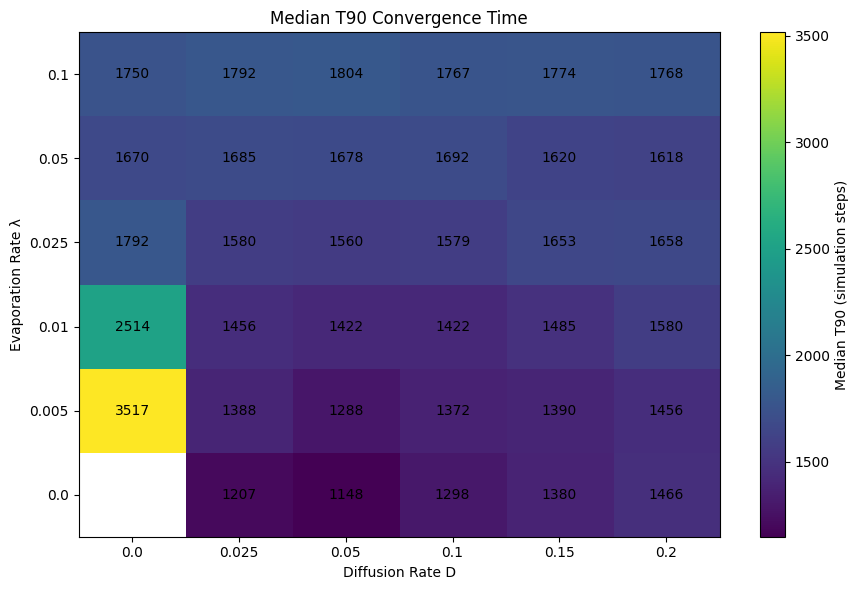

In [ ]:
diffusion_rates = [0.00, 0.025, 0.05, 0.10, 0.15, 0.20]
evaporation_rates = [0.00, 0.005, 0.01, 0.025, 0.05, 0.10]
n_trials = 30
max_steps = 20_000 # Maximum allowed runtime for one simulation
results = []

if __name__ == "__main__":

    for D in diffusion_rates:

        for evaporation in evaporation_rates:

            for trial in range(n_trials):

                seed = trial # Seed every trial differently

                sim = AntForagingSimulator(
                    rows_boxes=10,
                    cols_boxes=16,
                    n_ants=100,
                    colony=(5, 2),

                    food_sources=[
                        FoodSource(
                            position=(2, 14),
                            units=50,
                            label="Food 1",
                        )
                    ],

                    initial_search_fraction=0.20,
                    colony_wait_time=0,
                    maintain_search_fraction=True,

                    # Experimental Parameters
                    diffusion_rate=D,
                    evaporation_rate=evaporation,

                    # Control Parameters
                    deposition_rate=1.0,
                    pheromone_weight=3.0,
                    persistence_weight=0.0,
                    random_noise_weight=0.0,
                    return_randomness=0.0,

                    seed=seed,
                )

                metrics = sim.run(
                    max_steps=max_steps
                )

                results.append(
                    {
                        "diffusion_rate": D,
                        "evaporation_rate": evaporation,
                        "trial": trial,
                        "seed": seed,

                        "first_food_found":
                            metrics["first_food_found_step"],

                        "first_food_returned":
                            metrics["first_food_returned_step"],

                        "T50":
                            metrics["T50_step"],

                        "T90":
                            metrics["T90_step"],

                        "T100":
                            metrics["T100_step"],

                        "food_returned":
                            metrics["food_returned"],

                        "food_remaining":
                            metrics["food_remaining"],

                        "total_movement":
                            metrics["total_movement_steps"],

                        "movement_efficiency":
                            metrics["movement_efficiency"],

                        "completed":
                            sim.is_complete,
                    }
                )

            print(
                f"Finished D={D}, "
                f"evaporation={evaporation}"
            )

    # Convert results to a df and save each individual trial

    results_df = pd.DataFrame(results)

    print(results_df.head())

    results_df.to_csv(
        "experiment_1a_all_trials.csv",
        index=False,
    )

    # Median statistics for each parameter pair

    summary_df = (
        results_df
        .groupby(
            [
                "diffusion_rate",
                "evaporation_rate",
            ]
        )
        .agg(
            median_T90=("T90", "median"),
            median_T50=("T50", "median"),
            median_T100=("T100", "median"),
            median_first_discovery=(
                "first_food_found",
                "median",
            ),
            median_efficiency=(
                "movement_efficiency",
                "median",
            ),
            completion_rate=(
                "completed",
                "mean",
            ),
        )
        .reset_index()
    )

    summary_df.to_csv(
        "experiment_1a_summary.csv",
        index=False,
    )

    print()
    print("Summary")
    print(summary_df)

    # Generate heatmap for median T90

    heatmap_data = summary_df.pivot(
        index="evaporation_rate",
        columns="diffusion_rate",
        values="median_T90",
    )

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    image = ax.imshow(
        heatmap_data.values,
        origin="lower",
        aspect="auto",
    )

    ax.set_xticks(
        range(len(heatmap_data.columns))
    )

    ax.set_xticklabels(
        heatmap_data.columns
    )

    ax.set_yticks(
        range(len(heatmap_data.index))
    )

    ax.set_yticklabels(
        heatmap_data.index
    )

    ax.set_xlabel(
        "Diffusion Rate D"
    )

    ax.set_ylabel(
        "Evaporation Rate λ"
    )

    ax.set_title(
        "Median T90 Convergence Time"
    )

    colorbar = plt.colorbar(
        image,
        ax=ax,
    )

    colorbar.set_label(
        "Median T90 (simulation steps)"
    )

    # Write median T90 inside each heatmap cell
    for row in range(
        len(heatmap_data.index)
    ):
        for col in range(
            len(heatmap_data.columns)
        ):

            value = heatmap_data.iloc[
                row,
                col,
            ]

            if not np.isnan(value):
                ax.text(
                    col,
                    row,
                    f"{value:.0f}",
                    ha="center",
                    va="center",
                )

    plt.tight_layout()

    plt.savefig(
        "experiment_1a_T90_heatmap.png",
        dpi=300,
    )

    plt.show()

####Evaluation of Experiment 1a:

Evaluating the performance of D (diffusion rates) and λ (evaporation rates)

3 Methods:



*   Fastest Convergence
*   Most Reliable
*   Most Movement-Efficient

In [ ]:
# Fastest T90
best_speed = summary_df.loc[
    summary_df["median_T90"].idxmin()
]

# Highest completion rate
best_reliability = summary_df.loc[
    summary_df["completion_rate"].idxmax()
]

# Highest movement efficiency
best_efficiency = summary_df.loc[
    summary_df["median_efficiency"].idxmax()
]

print("\nFastest:")
print(best_speed)

print("\nMost reliable:")
print(best_reliability)

print("\nMost movement-efficient:")
print(best_efficiency)


Fastest:
diffusion_rate               0.050000
evaporation_rate             0.000000
median_T90                1147.500000
median_T50                 689.500000
median_T100               1271.000000
median_first_discovery     102.000000
median_efficiency            0.057319
completion_rate              1.000000
Name: 12, dtype: float64

Most reliable:
diffusion_rate               0.000000
evaporation_rate             0.005000
median_T90                3517.000000
median_T50                1975.500000
median_T100               3933.500000
median_first_discovery     102.000000
median_efficiency            0.018888
completion_rate              1.000000
Name: 1, dtype: float64

Most movement-efficient:
diffusion_rate               0.050000
evaporation_rate             0.000000
median_T90                1147.500000
median_T50                 689.500000
median_T100               1271.000000
median_first_discovery     102.000000
median_efficiency            0.057319
completion_rate          

####Interpretation of Evaluation:

A small diffusion rate helps nearby ants find the trail while still preserving directional information. Obviously it makes sense that the evaporation rate would be optimized at 0. Things clearly would be ideal for the ants if the pheromone trails never disappeared.
**median_first_discovery** and **median_T90**: The time between food first being discovered and 90% of it getting claimed is huge. Most of the time in the sim is spent transporting food. -> There could be 2 causes of this: the ants are not recruiting efficiently enough or it just naturally takes time to return the food.

### Experiment 1b: Ant Numbers

**Varying Active Forager Size**

Finished 5 active foragers (5%)
Finished 10 active foragers (10%)
Finished 20 active foragers (20%)
Finished 40 active foragers (40%)
Finished 60 active foragers (60%)
Finished 80 active foragers (80%)
Finished 100 active foragers (100%)

   active_foragers  median_T90  median_T50  median_T100  \
0                5      5808.5      3225.0       6321.0   
1               10      2721.0      1556.5       3071.0   
2               20      1287.5       773.5       1474.5   
3               40       717.0       469.0        783.0   
4               60       537.5       355.0        580.0   
5               80       451.0       316.0        484.0   
6              100       410.0       276.0        437.0   

   median_discovery_time  median_total_movement  median_efficiency  \
0                  150.0                32355.0           0.046361   
1                  120.0                31460.0           0.047680   
2                  102.0                30240.0           0.049605   
3       

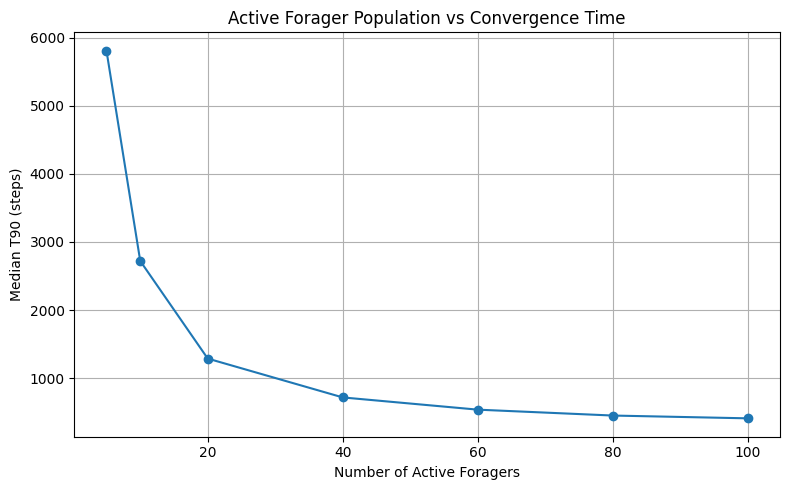

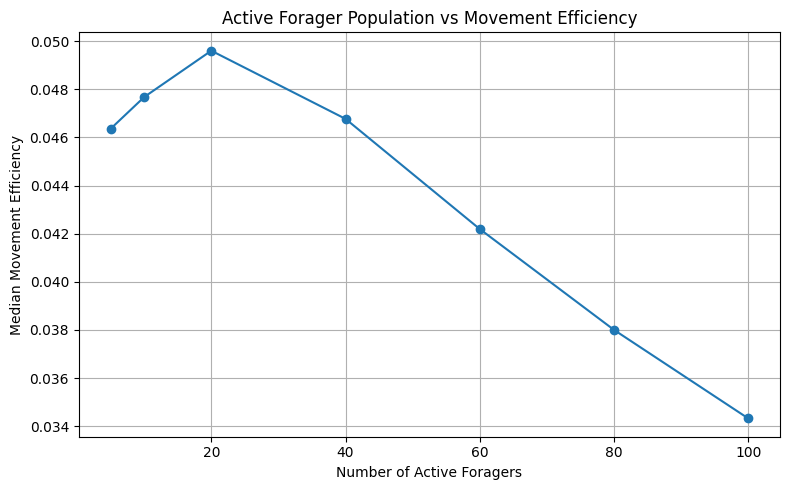

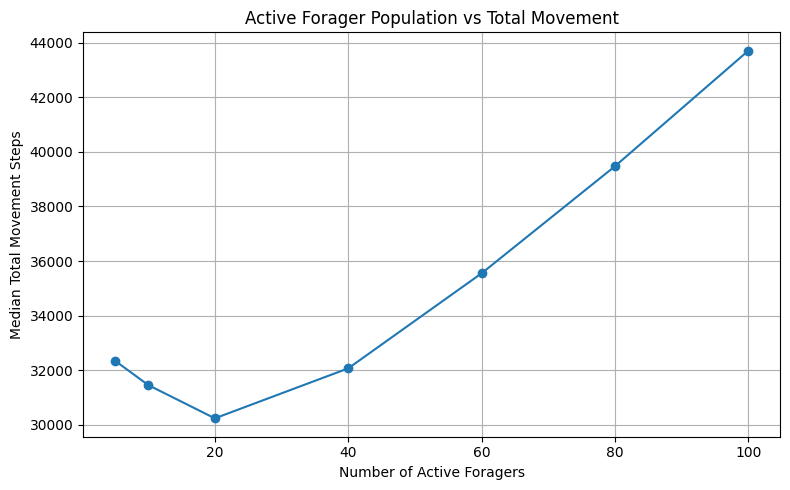

In [ ]:
total_colony_size = 100

search_fractions = [0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.00]
n_trials = 30
max_steps = 20_000

if __name__ == "__main__":

    # Use the D and lambda values selected from Experiment 1a
    best_diffusion_rate = 0.05
    best_evaporation_rate = 0.005

    results = []

    for search_fraction in search_fractions:

        active_foragers = int(
            round(
                total_colony_size
                * search_fraction
            )
        )

        for trial in range(n_trials):

            sim = AntForagingSimulator(
                rows_boxes=10,
                cols_boxes=16,

                # Total colony stays fixed
                n_ants=total_colony_size,

                colony=(5, 2),

                food_sources=[
                    FoodSource(
                        position=(2, 14),
                        units=50,
                        label="Food 1",
                    )
                ],

                # PARAMETER BEING TESTED
                initial_search_fraction=search_fraction,

                colony_wait_time=0,

                # Maintain the target number of active searchers
                maintain_search_fraction=True,

                # Fixed pheromone parameters
                diffusion_rate=best_diffusion_rate,
                evaporation_rate=best_evaporation_rate,
                deposition_rate=1.0,

                pheromone_weight=3.0,
                persistence_weight=0.0,
                random_noise_weight=0.0,
                return_randomness=0.0,

                seed=trial,
            )

            metrics = sim.run(
                max_steps=max_steps
            )

            results.append(
                {
                    "search_fraction":
                        search_fraction,

                    "active_foragers":
                        active_foragers,

                    "total_colony_size":
                        total_colony_size,

                    "trial":
                        trial,

                    "seed":
                        trial,

                    "first_food_found":
                        metrics[
                            "first_food_found_step"
                        ],

                    "first_food_returned":
                        metrics[
                            "first_food_returned_step"
                        ],

                    "T50":
                        metrics[
                            "T50_step"
                        ],

                    "T90":
                        metrics[
                            "T90_step"
                        ],

                    "T100":
                        metrics[
                            "T100_step"
                        ],

                    "food_returned":
                        metrics[
                            "food_returned"
                        ],

                    "food_remaining":
                        metrics[
                            "food_remaining"
                        ],

                    "total_movement":
                        metrics[
                            "total_movement_steps"
                        ],

                    "movement_efficiency":
                        metrics[
                            "movement_efficiency"
                        ],

                    "completed":
                        sim.is_complete,
                }
            )

        print(
            f"Finished "
            f"{active_foragers} active foragers "
            f"({search_fraction:.0%})"
        )

    # Convert to DataFrame

    results_df = pd.DataFrame(
        results
    )

    results_df.to_csv(
        "experiment_1b_all_trials.csv",
        index=False,
    )

    # Summary statistics

    summary_df = (
        results_df
        .groupby(
            "active_foragers"
        )
        .agg(
            median_T90=(
                "T90",
                "median",
            ),

            median_T50=(
                "T50",
                "median",
            ),

            median_T100=(
                "T100",
                "median",
            ),

            median_discovery_time=(
                "first_food_found",
                "median",
            ),

            median_total_movement=(
                "total_movement",
                "median",
            ),

            median_efficiency=(
                "movement_efficiency",
                "median",
            ),

            completion_rate=(
                "completed",
                "mean",
            ),
        )
        .reset_index()
    )

    summary_df.to_csv(
        "experiment_1b_summary.csv",
        index=False,
    )

    print()
    print(summary_df)


    # Plot 1: Median convergence time

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.plot(
        summary_df["active_foragers"],
        summary_df["median_T90"],
        marker="o",
    )

    ax.set_xlabel(
        "Number of Active Foragers"
    )

    ax.set_ylabel(
        "Median T90 (steps)"
    )

    ax.set_title(
        "Active Forager Population vs Convergence Time"
    )

    ax.grid(True)

    plt.tight_layout()

    plt.savefig(
        "experiment_1b_T90_vs_foragers.png",
        dpi=300,
    )

    plt.show()

    # Plot 2: Movement efficiency


    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.plot(
        summary_df["active_foragers"],
        summary_df["median_efficiency"],
        marker="o",
    )

    ax.set_xlabel(
        "Number of Active Foragers"
    )

    ax.set_ylabel(
        "Median Movement Efficiency"
    )

    ax.set_title(
        "Active Forager Population vs Movement Efficiency"
    )

    ax.grid(True)

    plt.tight_layout()

    plt.savefig(
        "experiment_1b_efficiency_vs_foragers.png",
        dpi=300,
    )

    plt.show()


    # Plot 3: Total ant movement

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.plot(
        summary_df["active_foragers"],
        summary_df["median_total_movement"],
        marker="o",
    )

    ax.set_xlabel(
        "Number of Active Foragers"
    )

    ax.set_ylabel(
        "Median Total Movement Steps"
    )

    ax.set_title(
        "Active Forager Population vs Total Movement"
    )

    ax.grid(True)

    plt.tight_layout()

    plt.savefig(
        "experiment_1b_total_movement_vs_foragers.png",
        dpi=300,
    )

    plt.show()